In [1]:
# ============================================================
# Copy required .py files from GitHub repo - branch flavio
# Excluding GNNShap and GECo
# ============================================================

import os
import shutil
import sys

# Go to Colab working directory
%cd /content

REPO_URL = "https://github.com/elenadigrigoli/Graph-Mining-and-Application-Project.git"
BRANCH = "flavio"
REPO_DIR = "/content/Graph-Mining-and-Application-Project"

# Remove old copy if it already exists
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

# Clone only the selected branch
!git clone -b flavio https://github.com/elenadigrigoli/Graph-Mining-and-Application-Project.git

# Destination: current notebook working directory
DEST_DIR = "/content"

# Python files to copy
PY_FILES = [
    "Model.py",
    "utils_graph.py",
    "CausGNN.py"
]

# Copy files
for file_name in PY_FILES:
    src = os.path.join(REPO_DIR, file_name)
    dst = os.path.join(DEST_DIR, file_name)

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Copied: {file_name}")
    else:
        print(f"WARNING: file not found -> {file_name}")

# Add /content to Python path
if DEST_DIR not in sys.path:
    sys.path.append(DEST_DIR)

print("\nAvailable .py files in /content:")
!ls /content/*.py

/content
Cloning into 'Graph-Mining-and-Application-Project'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (163/163), done.
remote: Total 198 (delta 26), reused 185 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (198/198), 15.09 MiB | 15.24 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Copied: Model.py
Copied: utils_graph.py
Copied: CausGNN.py

Available .py files in /content:
/content/CausGNN.py  /content/Model.py	/content/utils_graph.py


In [3]:
!pip install -q torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.0 MB/s eta 0:00:00


In [4]:
# ============================================================
# Import copied project modules
# ============================================================

from Model import *
from utils_graph import *
from CausGNN import *

print("Imports completed successfully.")

Imports completed successfully.


# **Explainable Graph AI using DGraphFin Dataset with a Graph Convolutional Network**

## 1. Import Dataset

In this first step, the DGraphFin dataset is downloaded from KaggleHub and loaded into memory.


In [5]:
import os
import kagglehub
import numpy as np

# Download the DGraphFin dataset from KaggleHub
dataset_path = kagglehub.dataset_download("gahoiambuj/dgraphfin")

# Locate the .npz file in the downloaded directory
npz_files = [file for file in os.listdir(dataset_path) if file.endswith(".npz")]

if not npz_files:
    raise FileNotFoundError("No .npz file was found in the downloaded dataset folder.")

dataset_file = npz_files[0]
dataset_file_path = os.path.join(dataset_path, dataset_file)

# Load the dataset
data = np.load(dataset_file_path, allow_pickle=True)

100%|██████████| 148M/148M [00:09<00:00, 16.2MB/s]

Extracting files...


## 2. Environment Setup

This notebook uses PyTorch Geometric to represent the DGraphFin dataset as a graph and to train the GCN model used as the prediction for the explainability experiments.



In [6]:
!pip install torch_geometric

### 2.1 Libraries

This section imports the main libraries used throughout the notebook.

PyTorch and PyTorch Geometric are used for graph representation and GCN training, scikit-learn for evaluation metrics, and Matplotlib/Seaborn/NetworkX for visual inspection of the graph explanations.

A fixed random seed is also defined to make the experiments more reproducible across runs.

In [7]:
import random
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (recall_score,roc_auc_score,)
from torch_geometric.data import Data
from torch_geometric.utils import (degree,index_to_mask,k_hop_subgraph,)

# Set a fixed seed for reproducibility
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# if torch.cuda.is_available():
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

# Select the available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


## 3. GCN Backbone Model

The explainability methods tested in this notebook are applied to a trained Graph Convolutional Network (GCN).  
The model consists of two graph convolutional layers, with an optional Batch Normalization layer and dropout between them.

This architecture is used as a common prediction backbone so that the different explainers can be compared on the same trained model and on the same target node.

In [8]:
import pandas as pd

# Convert node features, labels, and graph connectivity to PyTorch tensors
x = torch.from_numpy(data["x"]).float()
y = torch.from_numpy(data["y"]).long()
edge_index = torch.from_numpy(data["edge_index"]).long()

# PyTorch Geometric expects edge_index to have shape [2, num_edges]
if edge_index.dim() == 2 and edge_index.size(0) != 2:
    edge_index = edge_index.t().contiguous()

# Load optional edge attributes
edge_type = (torch.from_numpy(data["edge_type"]).long() if "edge_type" in data.files else None)

edge_time = (torch.from_numpy(data["edge_timestamp"]).long() if "edge_timestamp" in data.files else None)

# Convert dataset split indices into boolean masks
train_nodes = torch.from_numpy(data["train_mask"]).long()
val_nodes = torch.from_numpy(data["valid_mask"]).long()
test_nodes = torch.from_numpy(data["test_mask"]).long()

train_mask_original = index_to_mask(train_nodes, size=x.size(0))
val_mask_original = index_to_mask(val_nodes, size=x.size(0))
test_mask_original = index_to_mask(test_nodes, size=x.size(0))

# Build the PyTorch Geometric data object
graph_data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask_original,
    val_mask=val_mask_original,
    test_mask=test_mask_original,
    edge_type=edge_type,
    edge_time=edge_time,)


In [9]:
# Build the PyTorch Geometric data object
graph_data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask_original,
    val_mask=val_mask_original,
    test_mask=test_mask_original,
    edge_type=edge_type,
    edge_time=edge_time,
)

# Display a compact graph summary
graph_summary = pd.DataFrame(
    {
        "Property": [
            "Number of nodes",
            "Number of directed edges",
            "Number of node features",
            "Node feature matrix shape",
            "Label vector shape",
            "Edge index shape",
            "Edge type shape",
            "Edge timestamp shape",
        ],
        "Value": [
            graph_data.num_nodes,
            graph_data.num_edges,
            graph_data.num_node_features,
            tuple(graph_data.x.shape),
            tuple(graph_data.y.shape),
            tuple(graph_data.edge_index.shape),
            tuple(graph_data.edge_type.shape) if graph_data.edge_type is not None else "Not available",
            tuple(graph_data.edge_time.shape) if graph_data.edge_time is not None else "Not available",
        ],
    }
)

display(graph_summary)

# Display the full class distribution before binary filtering
classes, counts = torch.unique(graph_data.y, return_counts=True)

class_distribution = pd.DataFrame(
    {
        "Class label": classes.cpu().numpy(),
        "Number of nodes": counts.cpu().numpy(),
        "Percentage": (counts.float() / graph_data.num_nodes * 100).cpu().numpy().round(2),
    }
)

display(class_distribution)

print(graph_data)

,Property,Value
0,Number of nodes,3700550
1,Number of directed edges,4300999
2,Number of node features,17
3,Node feature matrix shape,"(3700550, 17)"
4,Label vector shape,"(3700550,)"
5,Edge index shape,"(2, 4300999)"
6,Edge type shape,"(4300999,)"
7,Edge timestamp shape,"(4300999,)"


,Class label,Number of nodes,Percentage
0,0,1210092,32.700001
1,1,15509,0.420000
2,2,1620851,43.799999
3,3,854098,23.080000


Data(x=[3700550, 17], edge_index=[2, 4300999], y=[3700550], train_mask=[3700550], val_mask=[3700550], test_mask=[3700550], edge_type=[4300999], edge_time=[4300999])


In [10]:
# Keep only labeled nodes belonging to the binary classification task
binary_mask = (graph_data.y == 0) | (graph_data.y == 1)

graph_data.train_mask = graph_data.train_mask & binary_mask
graph_data.val_mask = graph_data.val_mask & binary_mask
graph_data.test_mask = graph_data.test_mask & binary_mask

print(f"Number of training nodes: {graph_data.train_mask.sum().item()}\nNumber of validation nodes: {graph_data.val_mask.sum().item()}\nNumber of test nodes: {graph_data.test_mask.sum().item()}")

# count number of fraudulent nodes in the training set
num_fraudulent_train_nodes = (graph_data.train_mask & (graph_data.y == 1)).sum().item()
print(f"Number of fraudulent nodes in the training set: {num_fraudulent_train_nodes}")

# count number of fraudulent nodes in the validation set
num_fraudulent_val_nodes = (graph_data.val_mask & (graph_data.y == 1)).sum().item()
print(f"Number of fraudulent nodes in the validation set: {num_fraudulent_val_nodes}")

# count number of fraudulent nodes in the test set
num_fraudulent_test_nodes = (graph_data.test_mask & (graph_data.y == 1)).sum().item()
print(f"Number of fraudulent nodes in the test set: {num_fraudulent_test_nodes}")



Number of training nodes: 857899
Number of validation nodes: 183862
Number of test nodes: 183840
Number of fraudulent nodes in the training set: 10857
Number of fraudulent nodes in the validation set: 2326
Number of fraudulent nodes in the test set: 2326


## 4. Normalization

Before training the GCN, node features are standardized using only the training nodes.  
This avoids data leakage, because the statistics used for normalization are computed exclusively from the training split and then applied to the whole graph.

The graph is kept directed, preserving the original transaction direction provided by DGraphFin.  
Finally, the complete PyTorch Geometric `Data` object is moved to the selected device, either GPU if available or CPU otherwise.

In [11]:
# Compute normalization statistics using training nodes only
feature_mean = graph_data.x[graph_data.train_mask].mean(dim=0)
feature_std = graph_data.x[graph_data.train_mask].std(dim=0).clamp(min=1e-8)

# Standardize all node features using training statistics
graph_data.x = (graph_data.x - feature_mean) / feature_std

# Move the graph to the selected device
graph_data = graph_data.to(device)

print(f"Number of directed edges: {graph_data.num_edges:,}")

Number of directed edges: 4,300,999


## 5. GCN Initialization and Class Weighting

The GCN model is initialized using a compact set of hyperparameters.  
The architecture outputs two classes, corresponding to legitimate and fraudulent nodes.

Since the binary classification task is highly imbalanced, the training loss is weighted according to the class frequencies observed in the training split.  
This gives a larger penalty to mistakes on the minority fraud class and helps the model avoid being biased toward the majority legitimate class.

In [12]:
from Model import GCN

GCN_PARAMS = {
    "hidden_channels": 64,
    "dropout": 0.2,
    "batchnorm": False,
    "lr": 0.01,
    "weight_decay": 5e-7,
}

# Initialize the GCN model
model = GCN(
    in_channels=graph_data.num_node_features,
    hidden_channels=GCN_PARAMS["hidden_channels"],
    out_channels=2,
    dropout=GCN_PARAMS["dropout"],
    batchnorm=GCN_PARAMS["batchnorm"],
).to(device)

# Initialize the optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=GCN_PARAMS["lr"],
    weight_decay=GCN_PARAMS["weight_decay"],
)

# Compute class weights from the training split
train_labels = graph_data.y[graph_data.train_mask]

class_counts = torch.bincount(train_labels, minlength=2)
class_weights = class_counts.sum() / (2.0 * class_counts.float())
class_weights = class_weights.to(device)


# Display class counts and loss weights
class_weight_summary = pd.DataFrame(
    {
        "Class label": [0, 1],
        "Class meaning": ["Legitimate", "Fraud"],
        "Training nodes": class_counts.cpu().numpy(),
        "Loss weight": class_weights.detach().cpu().numpy().round(4),
    }
)

display(class_weight_summary)

print(model)

,Class label,Class meaning,Training nodes,Loss weight
0,0,Legitimate,847042,0.506400
1,1,Fraud,10857,39.508999


GCN(
  (conv1): GCNConv(17, 64)
  (conv2): GCNConv(64, 2)
)


### 5.1 Training and Evaluation Functions

The `train_epoch` function performs one full training step over the graph. Since the GCN returns log-probabilities, the weighted negative log-likelihood loss is used. The class weights computed from the training split are included to reduce the effect of class imbalance.

The `evaluate` function computes the main validation and test metrics used in this project:

- **AUC-ROC**, to measure the ranking quality between legitimate and fraudulent nodes;
- **Average Precision**, which is more informative under strong class imbalance;
- **Fraud recall**, to measure how many fraudulent nodes are correctly detected.

These metrics are more suitable than accuracy for this dataset, because the fraud class represents only a small fraction of the labeled nodes.

In [13]:
def train_epoch():
    """Run one training epoch and return the training loss."""
    model.train()
    optimizer.zero_grad()

    out = model(graph_data.x, graph_data.edge_index)

    loss = F.nll_loss(out[graph_data.train_mask],graph_data.y[graph_data.train_mask],weight=class_weights,)

    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(mask):
    """Evaluate the model on a given mask."""
    model.eval()

    out = model(graph_data.x, graph_data.edge_index)

    fraud_probabilities = out.exp()[:, 1]
    predictions = out.argmax(dim=1)

    y_true = graph_data.y[mask].detach().cpu().numpy()
    y_score = fraud_probabilities[mask].detach().cpu().numpy()
    y_pred = predictions[mask].detach().cpu().numpy()

    has_both_classes = len(np.unique(y_true)) > 1

    auc_roc = roc_auc_score(y_true, y_score) if has_both_classes else np.nan
    fraud_recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

    return {"auc_roc": auc_roc,"fraud_recall": fraud_recall,}

### 4.2 GCN Training with Early Stopping

The GCN is trained for a maximum number of epochs, while validation AUC-ROC is monitored to select the best model checkpoint.

Early stopping is used to avoid unnecessary training once the validation performance no longer improves.  
At each epoch, the training loss and validation metrics are stored in a history list, which will later be used to visualize the learning curves.

After training, the model parameters are restored to the best validation epoch and the final performance is evaluated on the test split.

In [14]:
epochs = 100
patience = 20

best_val_auc = -np.inf
best_epoch = 0
best_state = {key: value.detach().clone() for key, value in model.state_dict().items()}

epochs_without_improvement = 0
history = []

for epoch in range(1, epochs + 1):
    train_loss = train_epoch()

    val_metrics = evaluate(graph_data.val_mask)
    val_auc = val_metrics["auc_roc"]

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            **val_metrics,
        }
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        best_state = {
            key: value.detach().clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 10 == 0 or epoch == 1:
        train_metrics = evaluate(graph_data.train_mask)

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {train_loss:.4f} | "
            f"Train AUC-ROC: {train_metrics['auc_roc']:.4f} | "
            f"Val AUC-ROC: {val_metrics['auc_roc']:.4f} | "
            f"Val Fraud Recall: {val_metrics['fraud_recall']:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

Epoch 001 | Loss: 0.8160 | Train AUC-ROC: 0.5539 | Val AUC-ROC: 0.5541 | Val Fraud Recall: 0.4179
Epoch 010 | Loss: 0.6675 | Train AUC-ROC: 0.6438 | Val AUC-ROC: 0.6348 | Val Fraud Recall: 0.4759
Epoch 020 | Loss: 0.6554 | Train AUC-ROC: 0.6601 | Val AUC-ROC: 0.6558 | Val Fraud Recall: 0.7244
Epoch 030 | Loss: 0.6474 | Train AUC-ROC: 0.6675 | Val AUC-ROC: 0.6633 | Val Fraud Recall: 0.7261
Epoch 040 | Loss: 0.6454 | Train AUC-ROC: 0.6707 | Val AUC-ROC: 0.6656 | Val Fraud Recall: 0.7042
Epoch 050 | Loss: 0.6440 | Train AUC-ROC: 0.6741 | Val AUC-ROC: 0.6670 | Val Fraud Recall: 0.7034
Epoch 060 | Loss: 0.6417 | Train AUC-ROC: 0.6760 | Val AUC-ROC: 0.6684 | Val Fraud Recall: 0.7089
Epoch 070 | Loss: 0.6417 | Train AUC-ROC: 0.6776 | Val AUC-ROC: 0.6693 | Val Fraud Recall: 0.7077
Epoch 080 | Loss: 0.6408 | Train AUC-ROC: 0.6784 | Val AUC-ROC: 0.6700 | Val Fraud Recall: 0.7111
Epoch 090 | Loss: 0.6415 | Train AUC-ROC: 0.6791 | Val AUC-ROC: 0.6705 | Val Fraud Recall: 0.7089
Epoch 100 | Loss: 0.

In [15]:
# Restore the best model according to validation AUC-ROC
model.load_state_dict(best_state)

test_metrics = evaluate(graph_data.test_mask)

training_summary = pd.DataFrame(
    {
        "Metric": [
            "Best epoch",
            "Best validation AUC-ROC",
            "Test AUC-ROC",
            "Test Fraud Recall",
        ],
        "Value": [
            best_epoch,
            f"{best_val_auc:.4f}",
            f"{test_metrics['auc_roc']:.4f}",
            f"{test_metrics['fraud_recall']:.4f}",
        ],
    }
)

display(training_summary)

,Metric,Value
0,Best epoch,98
1,Best validation AUC-ROC,0.6709
2,Test AUC-ROC,0.6829
3,Test Fraud Recall,0.7214


### 4.3 Training Curves

,epoch,train_loss,auc_roc,fraud_recall
95,96,0.640670,0.670842,0.708083
96,97,0.640917,0.670849,0.707653
97,98,0.640097,0.670932,0.708942
98,99,0.640029,0.670880,0.708512
99,100,0.640441,0.670925,0.706793


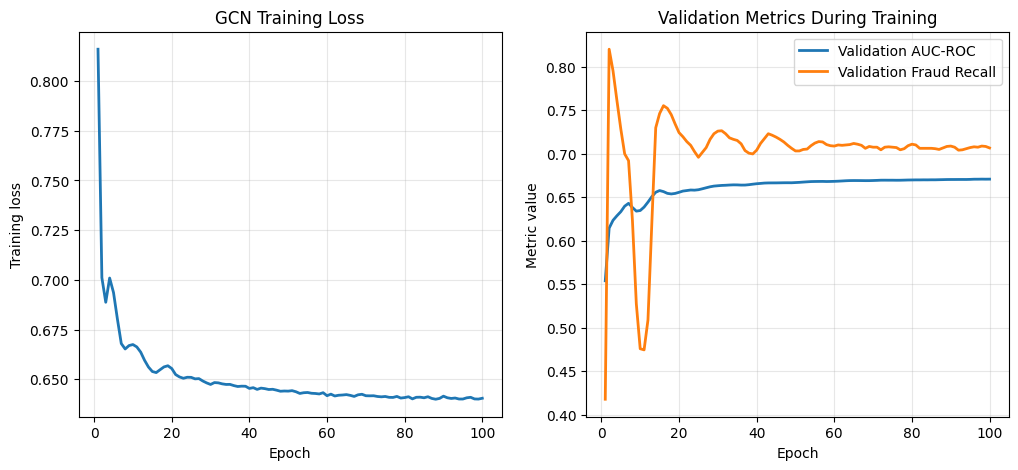

In [16]:
history_df = pd.DataFrame(history)

display(history_df.tail())

fig,ax = plt.subplots(1, 2,figsize=(12, 5))


ax[0].plot(history_df["epoch"], history_df["train_loss"], linewidth=2)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training loss")
ax[0].set_title("GCN Training Loss")
ax[0].grid(True, alpha=0.3)

ax[1].plot(history_df["epoch"], history_df["auc_roc"], label="Validation AUC-ROC", linewidth=2)
ax[1].plot(history_df["epoch"], history_df["fraud_recall"], label="Validation Fraud Recall", linewidth=2)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Metric value")
ax[1].set_title("Validation Metrics During Training")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.show()


The training curves show a coherent learning behavior.

The training loss decreases smoothly across epochs, suggesting that the GCN is progressively learning from the graph data.  
The validation AUC-ROC also increases gradually, reaching approximately `0.67`, which indicates an improvement in the model's ability to rank legitimate and fraudulent nodes.

The fraud recall is more unstable during the first epochs, but it later stabilizes around `0.70`, meaning that the model is able to correctly detect a relevant portion of the fraudulent nodes.



## 6. Target Fraud Node Selection

Before applying the explainability methods, a target node must be selected.

The objective is to explain a meaningful fraud prediction rather than an arbitrary node.  
For this reason, the selection procedure first identifies the nodes whose true label is fraud and then gives priority to those that are also correctly predicted as fraud by the trained GCN.

Among these candidates, the final target node is selected using a combined score based on:

- the predicted fraud probability;
- the local graph connectivity of the node.

This makes the selected node suitable for explanation, because it is both confidently classified as fraud and embedded in a sufficiently informative graph neighborhood.

In [17]:
from torch_geometric.utils import degree

# All fraud nodes
fraud_nodes = (graph_data.y == 1).nonzero(as_tuple=True)[0]

in_deg = degree(graph_data.edge_index[1],num_nodes=graph_data.num_nodes)

best_pos = torch.argmax(in_deg[fraud_nodes])
node_idx = int(fraud_nodes[best_pos].item())

print("Selected target node:", node_idx)
print("In-degree:", float(in_deg[node_idx].item()))

Selected target node: 624990
In-degree: 67.0


### 6.1 Local k-hop Subgraph Extraction

Most node-level explainability methods operate on the local computation graph of the target node rather than on the full graph.

For this reason, a `k`-hop subgraph is extracted around the selected fraud node.  
The subgraph contains the nodes and directed edges that can contribute to the target prediction through message passing.

A 3-hop neighborhood is used. This provides enough local context for the explainers while keeping the explanation problem computationally manageable.

In [18]:
k_hop = 3

subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
    node_idx=node_idx,
    num_hops = k_hop,
    edge_index=graph_data.edge_index,
    relabel_nodes=True,
    num_nodes=graph_data.num_nodes,
    flow="source_to_target",
)

sub_x = graph_data.x[subset]

target_sub_idx = int(mapping.item())
target_node_id = int(subset[target_sub_idx].item())

# Compute the degree of the target node inside the extracted subgraph
sub_in_degree = degree(sub_edge_index[1], num_nodes=sub_x.size(0))

sub_out_degree = degree(sub_edge_index[0], num_nodes=sub_x.size(0))


In [19]:
# Evaluate the trained model on the extracted local subgraph
model.eval()

with torch.no_grad():
    out_sub = model(sub_x, sub_edge_index)
    probs_sub = out_sub.exp()[target_sub_idx]
    pred_sub = int(probs_sub.argmax().item())

subgraph_summary = pd.DataFrame(
    {
        "Property": [
            "Number of hops",
            "Subgraph nodes",
            "Subgraph directed edges",
            "Target local index",
            "Target original node ID",
            "Matches selected target node",
            "Target local in-degree",
            "Target local out-degree",
            "True label",
            "Predicted class",
            "P(legitimate)",
            "P(fraud)",
        ],
        "Value": [
            k_hop,
            int(sub_x.size(0)),
            int(sub_edge_index.size(1)),
            target_sub_idx,
            target_node_id,
            node_idx == target_node_id,
            int(sub_in_degree[target_sub_idx].item()),
            int(sub_out_degree[target_sub_idx].item()),
            int(graph_data.y[target_node_id].item()),
            pred_sub,
            f"{probs_sub[0].item():.4f}",
            f"{probs_sub[1].item():.4f}",
        ],
    }
)

display(subgraph_summary)

,Property,Value
0,Number of hops,3
1,Subgraph nodes,89
2,Subgraph directed edges,92
3,Target local index,23
4,Target original node ID,624990
5,Matches selected target node,True
6,Target local in-degree,67
7,Target local out-degree,0
8,True label,1
9,Predicted class,1



The extracted 3-hop subgraph contains `89` nodes and `92` directed edges.  
The selected target node is correctly mapped from the original graph to the local subgraph, with local index `23`.


# 7. GNNExplainer

The first explanation method applied to the selected fraud prediction is **GNNExplainer**.

GNNExplainer learns a soft mask over the input graph in order to identify the components of the local computation graph that are most relevant for the model prediction.  
In this implementation, the explanation is focused on **structural node importance** by using `node_mask_type="object"`.

This means that the explainer assigns an importance score to each node in the local subgraph, rather than explaining individual node features.  
The edge mask is disabled in this experiment because edge-level gradients are not used in this GCN configuration.

The resulting node mask will be used to identify which neighboring nodes contribute most to the fraud prediction of the target node.


In [20]:
from torch_geometric.explain import Explainer, GNNExplainer


model.eval()

gnn_explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=100),
    explanation_type="model",
    node_mask_type="object",
    edge_mask_type=None,
    model_config={
        "mode": "multiclass_classification",
        "task_level": "node",
        "return_type": "log_probs",
    },
)

explanation_gnn = gnn_explainer(
    sub_x,
    sub_edge_index,
    index=target_sub_idx,
)

node_mask_gnn = explanation_gnn.node_mask.detach()

print(explanation_gnn)

Explanation(node_mask=[89, 1], prediction=[89, 2], target=[89], index=[1], x=[89, 17], edge_index=[2, 92])


In [21]:
node_scores_gnn = node_mask_gnn.view(-1).detach()
sub_edge_index = sub_edge_index.detach()

# Derive edge scores as the average importance of source and target nodes
edge_scores_gnn = (
    node_scores_gnn[sub_edge_index[0]] +
    node_scores_gnn[sub_edge_index[1]]
) / 2

gnn_edge_score_summary = pd.DataFrame(
    {
        "Property": [
            "Score type",
            "Edge scores shape",
            "Minimum edge score",
            "Maximum edge score",
            "Mean edge score",
            "Non-zero edge scores",
        ],
        "Value": [
            "Derived from node-object importance",
            tuple(edge_scores_gnn.shape),
            f"{edge_scores_gnn.min().item():.6f}",
            f"{edge_scores_gnn.max().item():.6f}",
            f"{edge_scores_gnn.mean().item():.6f}",
            int((edge_scores_gnn > 0).sum().item()),
        ],
    }
)

display(gnn_edge_score_summary)

,Property,Value
0,Score type,Derived from node-object importance
1,Edge scores shape,"(92,)"
2,Minimum edge score,0.126752
3,Maximum edge score,0.646737
4,Mean edge score,0.373176
5,Non-zero edge scores,92


In [22]:
top_k = 10

# Rank the most important nodes according to the GNNExplainer node mask
top_k_nodes = min(top_k, node_scores_gnn.numel())
top_node_values, top_node_indices = torch.topk(node_scores_gnn, k=top_k_nodes)

top_nodes_rows = []

for rank, local_idx in enumerate(top_node_indices, start=1):
    local_idx = int(local_idx.item())
    original_node_id = int(subset[local_idx].item())
    score = float(top_node_values[rank - 1].item())
    label_value = int(graph_data.y[original_node_id].item())

    if label_value == 1:
        label = "Fraud"
    elif label_value == 0:
        label = "Legitimate"
    else:
        label = f"Unknown ({label_value})"

    top_nodes_rows.append(
        {
            "Rank": rank,
            "Local node index": local_idx,
            "Original node ID": original_node_id,
            "Importance score": round(score, 4),
            "Label": label,
            "Is target node": local_idx == target_sub_idx,
        }
    )

top_gnn_nodes_df = pd.DataFrame(top_nodes_rows)
display(top_gnn_nodes_df)


,Rank,Local node index,Original node ID,Importance score,Label,Is target node
0,1,11,367206,0.7553,Legitimate,False
1,2,43,1090704,0.7312,Legitimate,False
2,3,1,66809,0.7283,Unknown (3),False
3,4,41,1015902,0.7278,Legitimate,False
4,5,28,711088,0.7276,Unknown (3),False
5,6,24,651964,0.7267,Unknown (3),False
6,7,45,1149842,0.7233,Legitimate,False
7,8,68,1784133,0.7175,Legitimate,False
8,9,20,595614,0.7137,Unknown (3),False
9,10,34,817281,0.7114,Legitimate,False


In [23]:
# Rank the most important derived edges
top_k_edges = min(top_k, edge_scores_gnn.numel())
top_edge_values, top_edge_indices = torch.topk(edge_scores_gnn, k=top_k_edges)

top_edges_rows = []

for rank, edge_idx in enumerate(top_edge_indices, start=1):
    edge_idx = int(edge_idx.item())

    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    source_original = int(subset[source_local].item())
    target_original = int(subset[target_local].item())

    score = float(top_edge_values[rank - 1].item())

    top_edges_rows.append(
        {
            "Rank": rank,
            "Edge index": edge_idx,
            "Source local index": source_local,
            "Target local index": target_local,
            "Source original ID": source_original,
            "Target original ID": target_original,
            "Derived edge score": round(score, 4),
            "Points to target node": target_local == target_sub_idx,
        }
    )

top_gnn_edges_df = pd.DataFrame(top_edges_rows)
display(top_gnn_edges_df)

,Rank,Edge index,Source local index,Target local index,Source original ID,Target original ID,Derived edge score,Points to target node
0,1,16,70,17,1853422,480097,0.6467,False
1,2,86,87,65,3590852,1737014,0.5591,False
2,3,24,11,23,367206,624990,0.5264,True
3,4,57,43,23,1090704,624990,0.5143,True
4,5,82,1,23,66809,624990,0.5129,True
5,6,85,41,23,1015902,624990,0.5127,True
6,7,9,28,23,711088,624990,0.5126,True
7,8,15,24,23,651964,624990,0.5121,True
8,9,53,45,23,1149842,624990,0.5104,True
9,10,43,68,23,1784133,624990,0.5075,True


In [24]:
top_k_edges = 10

top_edge_indices = top_gnn_edges_df["Edge index"].values
edge_scores = top_gnn_edges_df["Derived edge score"].values

important_edges = sub_edge_index[:, top_edge_indices]
important_edges_orig = subset[important_edges]

print("Top 10 important edges:")
for i in range(top_k_edges):
    src = important_edges_orig[0, i].item()
    dst = important_edges_orig[1, i].item()
    score = edge_scores[i].item()
    print(f"{i+1}. {src} -> {dst} | score = {score:.4f}")

Top 10 important edges:
1. 1853422 -> 480097 | score = 0.6467
2. 3590852 -> 1737014 | score = 0.5591
3. 367206 -> 624990 | score = 0.5264
4. 1090704 -> 624990 | score = 0.5143
5. 66809 -> 624990 | score = 0.5129
6. 1015902 -> 624990 | score = 0.5127
7. 711088 -> 624990 | score = 0.5126
8. 651964 -> 624990 | score = 0.5121
9. 1149842 -> 624990 | score = 0.5104
10. 1784133 -> 624990 | score = 0.5075


### 7.3 Visualization

The following plot visualizes the most relevant part of the local explanation produced by GNNExplainer.

Since the edge scores were derived from the object-level node importance mask, the visualization focuses on the top-ranked derived edges and the nodes connected by them.  
The target fraud node is highlighted separately, while the other nodes are colored according to their label.

Edge thickness is proportional to the derived importance score: thicker edges indicate connections between nodes that received higher structural importance from the explanation.

/tmp/ipykernel_6531/1433115182.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


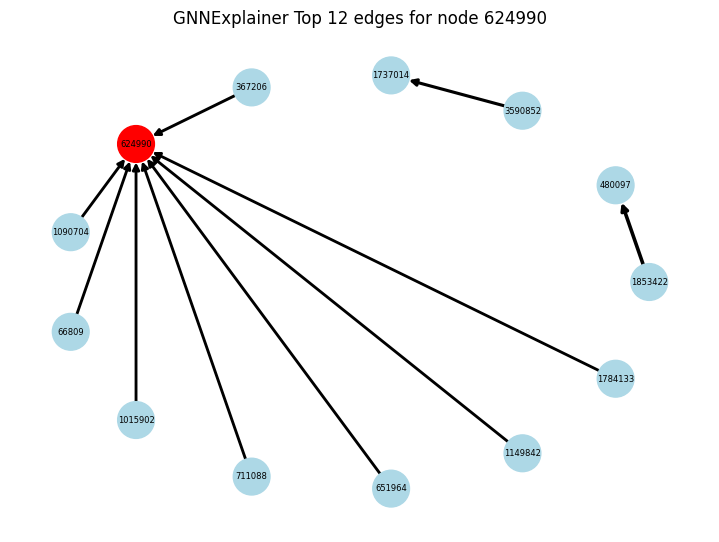

In [25]:
import networkx as nx

k_plot = 12
G = nx.DiGraph()

for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w = float(edge_scores[i].item())
    G.add_edge(src, dst, weight=w)

pos = nx.circular_layout(G)  # much faster than spring_layout
widths = [max(1.0, G[u][v]["weight"] * 4) for u, v in G.edges()]
colors = ["red" if n == node_idx else "lightblue" for n in G.nodes()]

plt.figure(figsize=(7, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=colors,
    width=widths,
    node_size=700,
    font_size=6,
    arrows=True
)
plt.title(f"GNNExplainer Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()



The visualization highlights the top derived structural connections identified from the GNNExplainer node-object mask.

All the most relevant derived edges point toward the selected target node, confirming that the fraud prediction is mainly supported by incoming neighbors in the local computation graph.  
The target node is clearly separated from the surrounding nodes and receives information from both legitimate and unknown-label nodes.

Since the edge scores are derived from node-object importance, they should be interpreted as a visualization aid rather than as a direct edge-level explanation.  
Overall, the plot suggests that GNNExplainer identifies a compact group of influential incoming neighbors as the main structural support for the fraud prediction.

# 8. GraphMaskExplainer

Unlike the previous GNNExplainer configuration, GraphMaskExplainer is used here as an edge-based explainer.  
Its goal is to identify which directed edges in the local computation graph are most relevant for preserving the model prediction.

In this experiment, node feature explanations are disabled, while the edge mask is enabled with `edge_mask_type="object"`.  
This allows the explanation to focus directly on the structural connections that support the GCN fraud prediction.

In [26]:
from torch_geometric.explain import GraphMaskExplainer

model.eval()

graphmask_explainer = Explainer(
    model=model,
    algorithm=GraphMaskExplainer(
        num_layers=2,
        epochs=100,
        lr=1e-3,
    ),
    explanation_type="model",
    node_mask_type=None,
    edge_mask_type="object",
    model_config={
        "mode": "multiclass_classification",
        "task_level": "node",
        "return_type": "log_probs",
    },
)

explanation_gma = graphmask_explainer(
    sub_x,
    sub_edge_index,
    index=target_sub_idx,
)

edge_mask_gma = explanation_gma.edge_mask

if edge_mask_gma is not None:
    edge_mask_gma = edge_mask_gma.detach().cpu()


print(explanation_gma)

Train explainer for node(s) tensor([23]) with layer 1: 100%|██████████| 100/100 [00:01<00:00, 91.36it/s] 
Train explainer for node(s) tensor([23]) with layer 0: 100%|██████████| 100/100 [00:01<00:00, 86.31it/s]
Explain: 100%|██████████| 2/2 [00:00<00:00, 489.16it/s]

Explanation(node_mask=[1, 17], edge_mask=[92], prediction=[89, 2], target=[89], index=[1], x=[89, 17], edge_index=[2, 92])


In [27]:
top_k = 10

# Select the highest-scoring edges from the GraphMask edge mask
top_k_edges_gma = min(top_k, edge_mask_gma.numel())

top_edge_values_gma, top_edge_indices_gma = torch.topk(
    edge_mask_gma,
    k=top_k_edges_gma,
)

top_graphmask_edges = []

for rank, edge_idx in enumerate(top_edge_indices_gma, start=1):
    edge_idx = int(edge_idx.item())

    # Retrieve local source and target nodes
    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    # Map local node indices back to original graph IDs
    source_original = int(subset[source_local].item())
    target_original = int(subset[target_local].item())

    edge_score = float(top_edge_values_gma[rank - 1].item())

    top_graphmask_edges.append(
        {
            "Rank": rank,
            "Edge index": edge_idx,
            "Source local index": source_local,
            "Target local index": target_local,
            "Source original ID": source_original,
            "Target original ID": target_original,
            "Edge importance score": round(edge_score, 4),
            "Points to target node": target_local == target_sub_idx,
        }
    )

top_graphmask_edges_df = pd.DataFrame(top_graphmask_edges)

display(top_graphmask_edges_df)

,Rank,Edge index,Source local index,Target local index,Source original ID,Target original ID,Edge importance score,Points to target node
0,1,61,33,23,813087,624990,1.0,True
1,2,56,83,67,3078237,1768104,1.0,False
2,3,57,43,23,1090704,624990,1.0,True
3,4,58,69,23,1819935,624990,1.0,True
4,5,59,57,55,1555327,1468696,1.0,False
5,6,60,50,23,1311036,624990,1.0,True
6,7,63,59,23,1579610,624990,1.0,True
7,8,65,88,67,3696583,1768104,1.0,False
8,9,64,60,23,1582822,624990,1.0,True
9,10,55,86,74,3550474,2088154,1.0,False


# 9. Integrated Gradients

Integrated Gradients requires a differentiable input with respect to which attribution scores can be computed.

Here, edge-level importance is estimated by treating the edge weights of the local subgraph as differentiable inputs.  
To avoid possible side effects from previous explainers, two clean GCN instances are created and initialized with the best trained checkpoint.

A sanity check is then performed to verify that the reference GCN and the edge-weight compatible GCN produce identical predictions before Integrated Gradients is applied.

In [30]:
! pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 24.0 MB/s eta 0:00:00


In [31]:
from torch_geometric.explain import Explainer, CaptumExplainer

explainer_ig = Explainer(
    model=model,
    algorithm=CaptumExplainer("IntegratedGradients"),
    explanation_type="phenomenon",
    node_mask_type="attributes",
    edge_mask_type=None,
    model_config=dict(
        mode="multiclass_classification",
        task_level="node",
        return_type="log_probs",
    ),
)
target = torch.full((sub_x.size(0),), 1, dtype=torch.long, device=sub_x.device)

explanation_ig = explainer_ig(
    x=sub_x,
    edge_index=sub_edge_index,
    index=target_sub_idx,
    target=target,  # fraud class per node
)

In [32]:
from utils_graph import compute_fidelity

node_mask_ig = explanation_ig.node_mask.mean(dim=-1).cpu()

base_score_ig, keep_score_ig, deletion_score_ig, important_nodes_ig = compute_fidelity(
    explanation=explanation_ig,
    model=model,
    sub_x=sub_x,
    sub_edge_index=sub_edge_index,
    target_sub_idx=target_sub_idx,
    threshold= 0,
    device=device,
 )

print(f"\n── Fidelity Integrated Gradients ───────────────────")
print(f"  P(fraud) baseline           : {base_score_ig:.4f}")
print(f"  P(fraud) keep test          : {keep_score_ig:.4f}  (Δ = {keep_score_ig - base_score_ig:+.4f})")
print(f"  P(fraud) deletion test      : {deletion_score_ig:.4f}  (Δ = {deletion_score_ig - base_score_ig:+.4f})")
print(f"  Nodes in explained subgraph : {len(important_nodes_ig)}")



── Fidelity Integrated Gradients ───────────────────
  P(fraud) baseline           : 1.0000
  P(fraud) keep test          : 1.0000  (Δ = +0.0000)
  P(fraud) deletion test      : 0.0064  (Δ = -0.9936)
  Nodes in explained subgraph : 77


In [33]:
# Extract and process node mask
node_mask_ig = explanation_ig.node_mask.mean(dim=-1)

# Derive edge scores from node importance
edge_scores_ig = (
    node_mask_ig[sub_edge_index[0]] + node_mask_ig[sub_edge_index[1]]
) / 2

# Normalize edge scores to [0, 1] for visualization
edge_scores_ig_norm = (
    (edge_scores_ig - edge_scores_ig.min()) /
    (edge_scores_ig.max() - edge_scores_ig.min() + 1e-8)
)

ig_summary = pd.DataFrame(
    {
        "Property": [
            "Explainer",
            "Explanation type",
            "Node mask type",
            "Edge mask type",
            "Subgraph nodes",
            "Subgraph directed edges",
            "Node mask shape",
            "Minimum node importance",
            "Maximum node importance",
            "Mean node importance",
            "Derived edge score minimum",
            "Derived edge score maximum",
            "Derived edge score mean",
            "Non-zero importance edges",
        ],
        "Value": [
            "Integrated Gradients (CaptumExplainer)",
            "Phenomenon explanation",
            "Attribute-level importance",
            "Disabled",
            int(sub_x.size(0)),
            int(sub_edge_index.size(1)),
            tuple(node_mask_ig.shape),
            f"{node_mask_ig.min().item():.6f}",
            f"{node_mask_ig.max().item():.6f}",
            f"{node_mask_ig.mean().item():.6f}",
            f"{edge_scores_ig_norm.min().item():.6f}",
            f"{edge_scores_ig_norm.max().item():.6f}",
            f"{edge_scores_ig_norm.mean().item():.6f}",
            int((edge_scores_ig_norm > 0).sum().item()),
        ],
    }
)

display(ig_summary)
print(explanation_ig)

,Property,Value
0,Explainer,Integrated Gradients (CaptumExplainer)
1,Explanation type,Phenomenon explanation
2,Node mask type,Attribute-level importance
3,Edge mask type,Disabled
4,Subgraph nodes,89
5,Subgraph directed edges,92
6,Node mask shape,"(89,)"
7,Minimum node importance,-0.054720
8,Maximum node importance,0.480828
9,Mean node importance,0.159928


Explanation(node_mask=[89, 17], target=[89], index=[1], x=[89, 17], edge_index=[2, 92])


In [34]:
top_k = 10

# Select the edges with the highest normalized IG scores
top_k_edges_ig = min(top_k, edge_scores_ig_norm.numel())

top_edge_values_ig, top_edge_indices_ig = torch.topk(
    edge_scores_ig_norm,
    k=top_k_edges_ig,
)

top_ig_edges = []

for rank, edge_idx in enumerate(top_edge_indices_ig, start=1):
    edge_idx = int(edge_idx.item())

    # Retrieve local source and target nodes
    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    # Map local node indices back to original graph IDs
    source_original = int(subset[source_local].item())
    target_original = int(subset[target_local].item())

    normalized_score = float(top_edge_values_ig[rank - 1].item())
    raw_attribution = float(edge_scores_ig[edge_idx].item())

    top_ig_edges.append(
        {
            "Rank": rank,
            "Edge index": edge_idx,
            "Source local index": source_local,
            "Target local index": target_local,
            "Source original ID": source_original,
            "Target original ID": target_original,
            "Normalized IG score": round(normalized_score, 4),
            "Raw IG attribution": round(raw_attribution, 4),
            "Contribution sign": "Positive" if raw_attribution >= 0 else "Negative",
            "Points to target node": target_local == target_sub_idx,
        }
    )

top_ig_edges_df = pd.DataFrame(top_ig_edges)

display(top_ig_edges_df)

,Rank,Edge index,Source local index,Target local index,Source original ID,Target original ID,Normalized IG score,Raw IG attribution,Contribution sign,Points to target node
0,1,60,50,23,1311036,624990,1.0000,0.2404,Positive,True
1,2,1,61,23,1640516,624990,1.0000,0.2404,Positive,True
2,3,13,72,23,2050088,624990,0.9831,0.2361,Positive,True
3,4,88,13,51,425451,1320838,0.9047,0.2161,Positive,False
4,5,74,44,23,1138108,624990,0.7365,0.1731,Positive,True
5,6,47,18,23,507320,624990,0.7365,0.1731,Positive,True
6,7,41,71,23,1869839,624990,0.7249,0.1701,Positive,True
7,8,75,58,23,1567601,624990,0.6841,0.1597,Positive,True
8,9,68,31,23,793574,624990,0.6841,0.1597,Positive,True
9,10,58,69,23,1819935,624990,0.6841,0.1597,Positive,True


/tmp/ipykernel_6531/3210612637.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


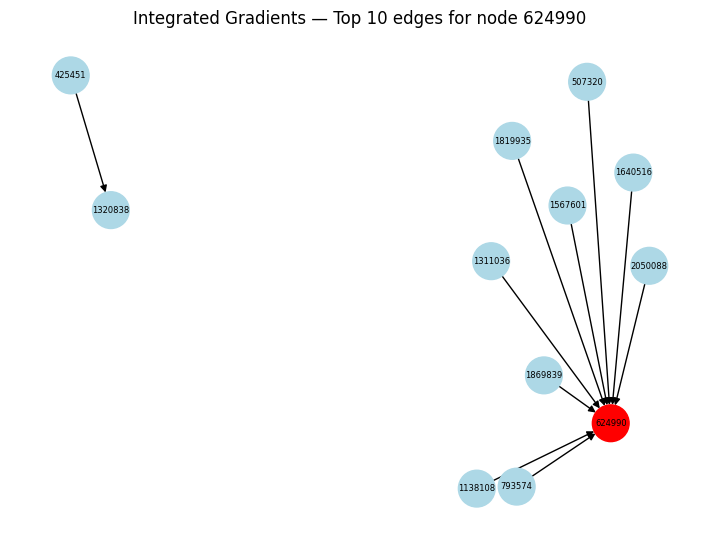

In [35]:
k_plot = 10

edge_scores_ig = (
    node_mask_ig[sub_edge_index[0].cpu()] + node_mask_ig[sub_edge_index[1].cpu()]
) / 2

top_k_idx = edge_scores_ig.argsort(descending=True)[:k_plot]
important_edges_orig = torch.stack([
    subset[sub_edge_index[0][top_k_idx]],
    subset[sub_edge_index[1][top_k_idx]],
])
edge_scores_topk = edge_scores_ig[top_k_idx]
node_idx = target_node_id

G = nx.DiGraph()
for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w   = float(edge_scores_topk[i].item())
    G.add_edge(src, dst, weight=w)

pos    = nx.spring_layout(G,scale=5,seed=24)  # much faster than spring_layout
widths = [max(1.0, G[u][v]["weight"] * 4) for u, v in G.edges()]
colors = ["red" if n == node_idx else "lightblue" for n in G.nodes()]

plt.figure(figsize=(7, 5))
nx.draw(G, pos, with_labels=True, node_color=colors,
        width=widths, node_size=700, font_size=6, arrows=True)
plt.title(f"Integrated Gradients — Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()



All the relevant edges point directly toward the target node, confirming that the prediction is mainly driven by incoming structural information from neighboring nodes.  

The highest-ranked edge comes from node `595614` and has the maximum normalized IG score of `1.00`, with a positive raw attribution. This means that this edge strongly supports the fraud prediction.  
Other edges also support the prediction, such as those from nodes `817281`, `421328`, `66809`, and `1149842`.

At the same time, some highly ranked edges have negative raw attribution values. These edges are still important in absolute terms, but they push against the fraud prediction rather than supporting it.  
This distinction is useful because Integrated Gradients does not only identify important edges, but also shows whether each edge increases or decreases the predicted fraud probability.

Overall, the visualization suggests that the GCN prediction for the target node is influenced by a set of incoming neighbors with mixed effects: some edges reinforce the fraud classification, while others partially contrast it.

# 10. CausGNN

A CausGNN-style explainer is implemented to obtain a node-level structural explanation for the selected fraud prediction.

The explainer learns a soft mask over the nodes of the local subgraph.  
This mask does not explain individual node features; instead, it assigns an importance score to each node as a graph object.

The optimization follows a factual/counterfactual logic:

- in the factual branch, important nodes are kept active and the fraud prediction should be preserved;
- in the counterfactual branch, important nodes are removed and the fraud probability should decrease;
- sparsity encourages the explanation to focus on a smaller subset of nodes;
- entropy regularization encourages the learned mask to become closer to a binary selection.

The target node is always kept active to avoid producing explanations that simply remove the node being explained.

In [43]:

from CausGNN import run_causgnn_explainer

In [47]:
# This cell runs the external CausGNN implementation on the selected local subgraph.

caus_mask, caus_base, caus_pred, caus_history_df = run_causgnn_explainer(
    model=model,
    sub_x=sub_x,
    sub_edge_index=sub_edge_index,
    target_sub_idx=target_sub_idx,
    target_class=1,
    lambda_cf=0.5,
    lambda_sparsity=0.08,
    lambda_entropy=0.02,
    epochs=200,
    lr=0.01,
    device=device,
    verbose=False,
)

sorted_caus = caus_mask.argsort(descending=True)

print(f"\n{'Local idx':>10} | {'Node ID':>12} | {'Causal score':>13} | {'Label':>8}")
print("-" * 55)

for i in sorted_caus[:10]:
    local_idx = int(i.item())
    orig = int(subset[local_idx].item())
    score = float(caus_mask[local_idx].item())

    label_value = int(graph_data.y[orig].item())
    label = "FRAUD" if label_value == 1 else "legit"

    marker = " ← TARGET" if local_idx == target_sub_idx else ""

    print(f"{local_idx:>10} | {orig:>12} | {score:>13.4f} | {label:>8}{marker}")


 Local idx |      Node ID |  Causal score |    Label
-------------------------------------------------------
        23 |       624990 |        1.0000 |    FRAUD ← TARGET
        85 |      3543729 |        0.3130 |    legit
        53 |      1360327 |        0.2981 |    legit
        15 |       475280 |        0.2945 |    legit
        36 |       907650 |        0.2833 |    legit
        44 |      1138108 |        0.2737 |    legit
         9 |       359575 |        0.2445 |    legit
        38 |       926750 |        0.2365 |    legit
        55 |      1468696 |        0.2338 |    legit
         1 |        66809 |        0.2305 |    legit


/tmp/ipykernel_6531/3167809698.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


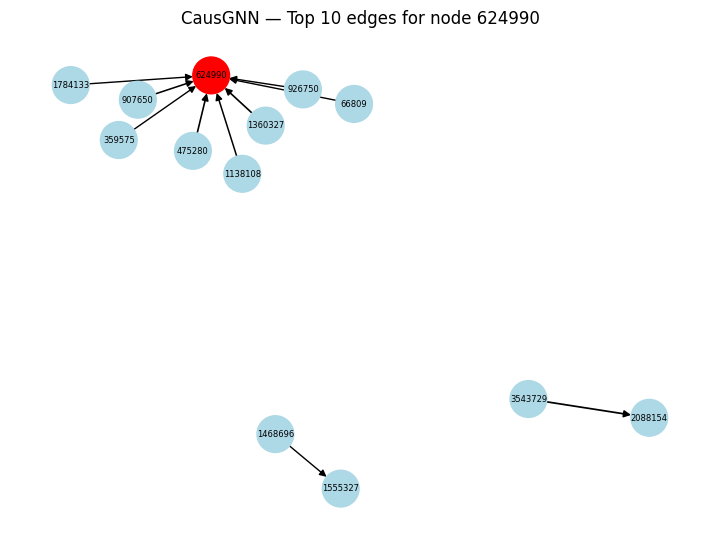

In [48]:
# This cell visualizes the top edges derived from the CausGNN node-level causal scores.

k_plot = 10

sub_edge_index_cpu = sub_edge_index.detach().cpu()

# Edge score = source node causal score
edge_scores_caus = caus_mask[sub_edge_index_cpu[0]]

top_k_idx = edge_scores_caus.argsort(descending=True)[:k_plot]

important_edges_orig = torch.stack(
    [
        subset[sub_edge_index_cpu[0][top_k_idx]],
        subset[sub_edge_index_cpu[1][top_k_idx]],
    ]
)

edge_scores_topk = edge_scores_caus[top_k_idx]

node_idx = target_node_id

G = nx.DiGraph()

for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w = float(edge_scores_topk[i].item())

    G.add_edge(src, dst, weight=w)

pos = nx.spring_layout(G, scale=5, seed=18)

widths = [
    max(1.0, G[u][v]["weight"] * 4)
    for u, v in G.edges()
]

colors = [
    "red" if n == node_idx else "lightblue"
    for n in G.nodes()
]

plt.figure(figsize=(7, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    width=widths,
    node_size=700,
    font_size=6,
    arrows=True,
)

plt.title(f"CausGNN — Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()

# 11. GECo

This section initializes the GECo explainer using the installed `geco_explainer` package.

The GECo implementation expects the GNN model to follow the interface:

```python
gnn(x, edge_index, batch)
```
while the trained GCN used in this notebook follows:

```python
gnn(x, edge_index, batch)
```

For this reason, a lightweight adapter is defined. The adapter receives the optional batch argument required by GECo, but forwards only x and edge_index to the trained GCN.

In [ ]:
import os
import sys
import torch.nn as nn
from geco_explainer.geco_explainer import GECo

repo_root = os.path.abspath(".")
geco_root = os.path.join(repo_root, "geco_explainer")
if geco_root not in sys.path:
    sys.path.insert(0, geco_root)

class ModelAdapter(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x, edge_index, batch=None):
        return self.base_model(x, edge_index)

geco = GECo(device, ModelAdapter(model))
pred, probs = geco.predict(graph_data)
print("GECo import ok, pred:", pred)

GECo import ok, pred: 1


### 11.1 Build GECo local k-hop subgraph and predict

GECo is applied to a local neighborhood around the selected target fraud node.

A larger `k`-hop neighborhood is used for this explainer, following the setup tested in the reference code.  
The extracted subgraph is converted into a PyTorch Geometric `Data` object and provided with a `batch` vector, because the GECo implementation may expect graph-level inputs.

The GECo `predict` method is then tested on the local subgraph to verify that the library can run with the adapted GCN.

In [ ]:
k_hop_geco = 5

# Extract a larger local subgraph for GECo
subset_geco, sub_edge_index_geco, mapping_geco, edge_mask_geco = k_hop_subgraph(
    node_idx=node_idx,
    num_hops=k_hop_geco,
    edge_index=graph_data.edge_index,
    relabel_nodes=True,
    num_nodes=graph_data.num_nodes,
    flow="source_to_target",
)

sub_x_geco = graph_data.x[subset_geco]
target_sub_idx_geco = int(mapping_geco.item())
target_node_id_geco = int(subset_geco[target_sub_idx_geco].item())

# Build PyG Data object expected by GECo
sub_data_geco = Data(
    x=sub_x_geco,
    edge_index=sub_edge_index_geco,
    y=graph_data.y[subset_geco],
)

# Some GECo implementations expect a batch vector
sub_data_geco.batch = torch.zeros(
    sub_x_geco.size(0),
    dtype=torch.long,
    device=device,
)

sub_data_geco = sub_data_geco.to(device)

# Test GECo prediction on the local subgraph
pred_geco, probs_geco = geco.predict(sub_data_geco)

geco_prediction_summary = pd.DataFrame(
    {
        "Property": [
            "GECo k-hop",
            "Subgraph nodes",
            "Subgraph directed edges",
            "Target local index",
            "Target original node ID",
            "Matches selected target node",
            "Target true label",
            "GECo predicted class",
            "Returned probabilities",
        ],
        "Value": [
            k_hop_geco,
            int(sub_data_geco.num_nodes),
            int(sub_data_geco.edge_index.size(1)),
            target_sub_idx_geco,
            target_node_id_geco,
            target_node_id_geco == target_node_id,
            int(graph_data.y[target_node_id_geco].item()),
            int(pred_geco),
            str(probs_geco),
        ],
    }
)

display(geco_prediction_summary)

,Property,Value
0,GECo k-hop,5
1,Subgraph nodes,91
2,Subgraph directed edges,94
3,Target local index,23
4,Target original node ID,624990
5,Matches selected target node,True
6,Target true label,1
7,GECo predicted class,1
8,Returned probabilities,[0.31755242 0.6824477 ]



For the GECo experiment, a larger `5`-hop subgraph was extracted around the selected target node.

The resulting local graph contains `91` nodes and `94` directed edges.  
The selected target node is correctly mapped inside the GECo subgraph, with original node ID `624990` and true label `1`, corresponding to the fraud class.

The GECo prediction output returns predicted class `47`, which is not directly comparable to the binary node-level prediction of the trained GCN.  
This suggests that the installed GECo implementation is likely treating the input in a graph-level or community-level way rather than as a standard node-level binary classifier.

For this reason, the GECo prediction is used mainly as a compatibility check.  
The explanation step is still forced on class `1`, because the goal of this notebook is to explain the fraud prediction of the selected target node.

### 11.3  GECo Explanation on the Local Subgraph and Visualization


Since the objective of this project is to explain the fraud prediction of the selected target node, the explanation class is set to `1`, corresponding to the fraud class.

The returned GECo explanation is inspected and, when possible, local node indices are mapped back to the original DGraphFin node IDs.  
This makes the result easier to compare with the other explainers used in the notebook.

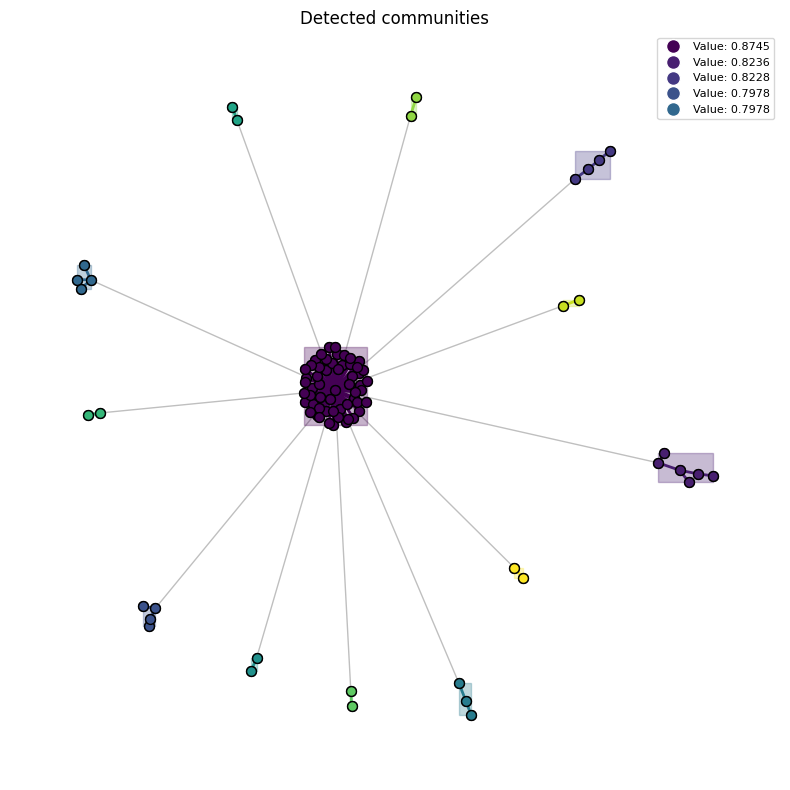

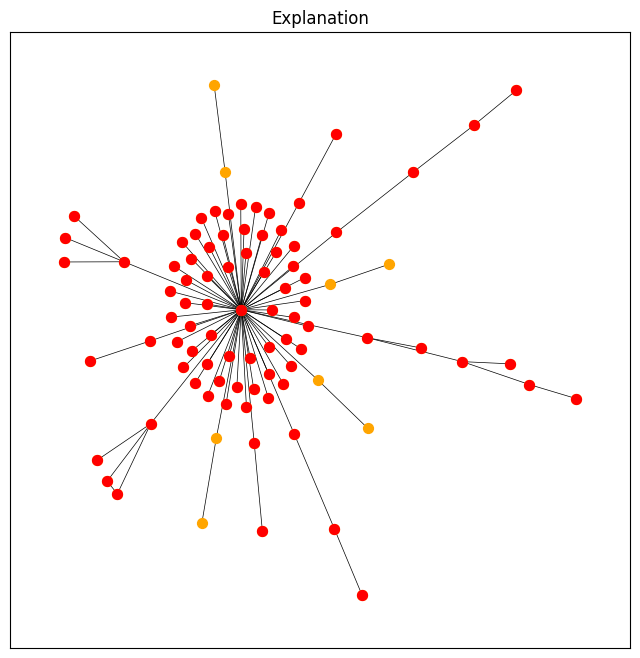

Tau 0.628318102313922
1. Community [58, 55] (2 nodes) - Probability: 0.8745
2. Community [89, 66, 82] (3 nodes) - Probability: 0.8236
3. Community [84, 37, 68, 85, 73, 90] (6 nodes) - Probability: 0.8228
4. Community [51, 13] (2 nodes) - Probability: 0.7978
5. Community [17, 71] (2 nodes) - Probability: 0.7978
6. Community [16, 88, 76, 87] (4 nodes) - Probability: 0.7856
7. Community [64, 65, 30, 86] (4 nodes) - Probability: 0.7011
8. Community [0, 1, 2, 3, 4, 7, 9, 10, 11, 12, 14, 15, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 31, 33, 34, 35, 36, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 57, 59, 60, 61, 62, 63, 67, 69, 70, 72, 74, 78, 79, 80] (56 nodes) - Probability: 0.6925
9. Community [56, 26, 83, 77] (4 nodes) - Probability: 0.6423
10. Community [40, 5] (2 nodes) - Probability: 0.3727
11. Community [32, 75] (2 nodes) - Probability: 0.3726
12. Community [8, 38] (2 nodes) - Probability: 0.3712
13. Community [81, 6] (2 nodes) - Probability: 0.1137


In [ ]:
graph = sub_data_geco
exp = geco.explain(graph, int(pred_sub), visualize=True, verbose=True)

### GECo Detected Communities Summary

The GECo library detects several communities inside the local `5`-hop subgraph.

The visualization shows a dense central community connected to multiple smaller peripheral communities.  
This structure is consistent with the topology of the local neighborhood, where the selected target region is surrounded by several small groups of connected nodes.

The legend reports a probability value for each detected community.  
These values indicate the relevance or confidence assigned by GECo to the corresponding communities during the explanation process.

This output confirms that GECo is operating at a community level rather than simply ranking individual edges or nodes.  
Compared with the previous explainers, GECo therefore provides a more group-based interpretation of the local graph structure.
### GECo Explanation Visualization Summary

The GECo explanation plot highlights the portion of the local subgraph selected as relevant for the target class.

The central region of the graph contains many selected nodes, while additional nodes and branches are distributed around it.  
This suggests that GECo identifies a broader explanatory structure rather than only the immediate incoming edges of the target node.

Unlike GNNExplainer, GraphMaskExplainer, Integrated Gradients, and the CausGNN-style explainer, GECo focuses on communities and graph regions.  
Therefore, its explanation should be interpreted as a structural subgraph or community-level explanation, not as a direct edge-importance ranking.

The plot also shows that GECo selects both central and peripheral nodes, indicating that the fraud-related explanation may depend on multiple local structural groups.

# 12.  GraphEXT

This explainer learns a soft mask over the edges of the local subgraph.  
Unlike node-based explainers, this method assigns importance directly to edges, without using feature masks or node feature attributions.

The objective is designed to preserve the fraud prediction of the target node while encouraging the learned edge mask to remain compact and close to a binary selection.  
In this way, the explainer tries to identify a small set of relevant edges that are sufficient to maintain the target fraud prediction.

The trained GCN copy compatible with explicit edge weights is used for this step.

In [49]:
# This cell defines a compact GraphEXT-style explainer that learns a soft mask over subgraph edges.

import torch
import torch.nn as nn
import networkx as nx
import matplotlib.pyplot as plt

try:
    from torch_geometric.explain.algorithm.utils import set_masks, clear_masks
except ImportError:
    from torch_geometric.nn.models.explainer import set_masks, clear_masks


def run_graphext_explainer(
    model,
    sub_x,
    sub_edge_index,
    target_sub_idx,
    target_class=1,
    epochs=200,
    lr=0.01,
    lambda_sparsity=0.05,
    lambda_entropy=0.02,
    device=device,
    verbose=False,
):
    model.eval()

    sub_x = sub_x.to(device)
    sub_edge_index = sub_edge_index.to(device)

    edge_logits = nn.Parameter(torch.randn(sub_edge_index.size(1), device=device) * 0.1)
    optimizer = torch.optim.Adam([edge_logits], lr=lr)

    with torch.no_grad():
        base_out = model(sub_x, sub_edge_index)
        base_score = float(base_out.exp()[target_sub_idx, target_class].item())

    for epoch in range(epochs):
        optimizer.zero_grad()

        edge_mask = torch.sigmoid(edge_logits)

        set_masks(model, edge_mask, sub_edge_index, apply_sigmoid=False)
        out = model(sub_x, sub_edge_index)
        clear_masks(model)

        prob = out.exp()[target_sub_idx, target_class]

        loss_pred = -torch.log(prob + 1e-8)
        loss_sparse = edge_mask.mean()
        loss_entropy = -(
            edge_mask * torch.log(edge_mask + 1e-8)
            + (1 - edge_mask) * torch.log(1 - edge_mask + 1e-8)
        ).mean()

        loss = loss_pred + lambda_sparsity * loss_sparse + lambda_entropy * loss_entropy

        loss.backward()
        optimizer.step()

        if verbose and epoch % 50 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {loss.item():.4f} | "
                f"P(fraud): {prob.item():.4f} | "
                f"Mask mean: {edge_mask.mean().item():.4f}"
            )

    clear_masks(model)

    with torch.no_grad():
        edge_scores = torch.sigmoid(edge_logits).detach().cpu()
        edge_scores = (edge_scores - edge_scores.min()) / (
            edge_scores.max() - edge_scores.min() + 1e-8
        )

    return edge_scores, base_score

In [50]:
# This cell runs GraphEXT and prints the most important edges in the local subgraph.

edge_scores_graphext, graphext_base = run_graphext_explainer(
    model=model,
    sub_x=sub_x,
    sub_edge_index=sub_edge_index,
    target_sub_idx=target_sub_idx,
    target_class=1,
    epochs=200,
    lr=0.01,
    lambda_sparsity=0.05,
    lambda_entropy=0.02,
    device=device,
    verbose=False,
)

sorted_graphext = edge_scores_graphext.argsort(descending=True)

print(f"\nGraphEXT baseline P(fraud): {graphext_base:.4f}")
print(f"\n{'Edge idx':>8} | {'Source ID':>12} | {'Target ID':>12} | {'Score':>8} | {'To target':>9}")
print("-" * 65)

for edge_idx in sorted_graphext[:10]:
    edge_idx = int(edge_idx.item())

    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    source_orig = int(subset[source_local].item())
    target_orig = int(subset[target_local].item())

    score = float(edge_scores_graphext[edge_idx].item())
    to_target = "YES" if target_local == target_sub_idx else "NO"

    print(
        f"{edge_idx:>8} | "
        f"{source_orig:>12} | "
        f"{target_orig:>12} | "
        f"{score:>8.4f} | "
        f"{to_target:>9}"
    )


GraphEXT baseline P(fraud): 1.0000

Edge idx |    Source ID |    Target ID |    Score | To target
-----------------------------------------------------------------
      78 |      1308009 |       624990 |   1.0000 |       YES
      61 |       813087 |       624990 |   0.9677 |       YES
      52 |      2689391 |       667636 |   0.9080 |        NO
      62 |      1737014 |       624990 |   0.8435 |       YES
      70 |       919734 |       624990 |   0.8122 |       YES
      51 |      2088154 |       624990 |   0.7992 |       YES
      71 |      2118403 |       624990 |   0.7848 |       YES
       7 |      1766657 |       624990 |   0.7691 |       YES
      67 |       475280 |       624990 |   0.7396 |       YES
      40 |      2256264 |       624990 |   0.7254 |       YES


/tmp/ipykernel_6531/2418554363.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


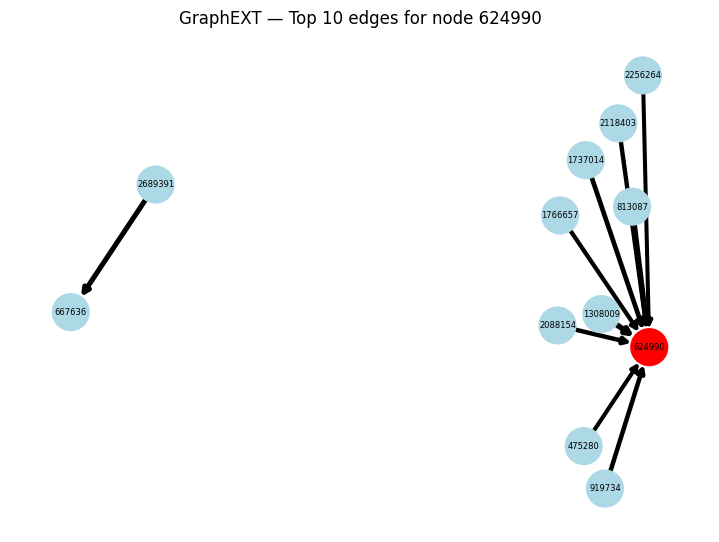

In [51]:
# This cell visualizes the top GraphEXT edges using the learned edge-level scores.

k_plot = 10

top_k_idx = edge_scores_graphext.argsort(descending=True)[:k_plot]

important_edges_orig = torch.stack(
    [
        subset[sub_edge_index[0].cpu()[top_k_idx]],
        subset[sub_edge_index[1].cpu()[top_k_idx]],
    ]
)

edge_scores_topk = edge_scores_graphext[top_k_idx]
node_idx = target_node_id

G = nx.DiGraph()

for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w = float(edge_scores_topk[i].item())

    G.add_edge(src, dst, weight=w)

pos = nx.spring_layout(G, scale=5, seed=18)

widths = [
    max(1.0, G[u][v]["weight"] * 4)
    for u, v in G.edges()
]

colors = [
    "red" if n == node_idx else "lightblue"
    for n in G.nodes()
]

plt.figure(figsize=(7, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    width=widths,
    node_size=700,
    font_size=6,
    arrows=True,
)

plt.title(f"GraphEXT — Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()

# 13. ORExplainer

An ORExplainer-style structural explainer is implemented as an additional edge-based explanation method.

The explainer learns a soft mask over the directed edges of the local subgraph.  
The explanation is therefore structural: no node feature mask is learned and no feature-level attribution is produced.

The objective preserves the fraud prediction of the target node while penalizing large explanations and encouraging the learned edge mask to become close to binary values.  
Compared with the previous GraphEXT-style explainer, this implementation uses a slightly stronger size and entropy regularization, making it more focused on selecting a compact set of relevant edges.

The trained GCN copy compatible with explicit edge weights is used for this step.

In [52]:
# This cell defines a compact ORExplainer-style method that learns an edge mask using factual and counterfactual objectives.

import torch
import torch.nn as nn
import networkx as nx
import matplotlib.pyplot as plt

try:
    from torch_geometric.explain.algorithm.utils import set_masks, clear_masks
except ImportError:
    from torch_geometric.nn.models.explainer import set_masks, clear_masks


def run_orexplainer(
    model,
    sub_x,
    sub_edge_index,
    target_sub_idx,
    target_class=1,
    epochs=200,
    lr=0.01,
    lambda_cf=0.5,
    lambda_sparsity=0.05,
    lambda_entropy=0.02,
    device=device,
    verbose=False,
):
    model.eval()

    sub_x = sub_x.to(device)
    sub_edge_index = sub_edge_index.to(device)

    edge_logits = nn.Parameter(torch.randn(sub_edge_index.size(1), device=device) * 0.1)
    optimizer = torch.optim.Adam([edge_logits], lr=lr)

    with torch.no_grad():
        base_out = model(sub_x, sub_edge_index)
        base_score = float(base_out.exp()[target_sub_idx, target_class].item())

    for epoch in range(epochs):
        optimizer.zero_grad()

        edge_mask = torch.sigmoid(edge_logits)

        # Factual branch: keep the selected edges
        set_masks(model, edge_mask, sub_edge_index, apply_sigmoid=False)
        out_factual = model(sub_x, sub_edge_index)
        clear_masks(model)

        prob_factual = out_factual.exp()[target_sub_idx, target_class]
        loss_factual = -torch.log(prob_factual + 1e-8)

        # Counterfactual branch: remove the selected edges
        cf_mask = 1.0 - edge_mask

        set_masks(model, cf_mask, sub_edge_index, apply_sigmoid=False)
        out_counterfactual = model(sub_x, sub_edge_index)
        clear_masks(model)

        prob_counterfactual = out_counterfactual.exp()[target_sub_idx, target_class]
        loss_counterfactual = prob_counterfactual

        loss_sparse = edge_mask.mean()

        loss_entropy = -(
            edge_mask * torch.log(edge_mask + 1e-8)
            + (1 - edge_mask) * torch.log(1 - edge_mask + 1e-8)
        ).mean()

        loss = (
            loss_factual
            + lambda_cf * loss_counterfactual
            + lambda_sparsity * loss_sparse
            + lambda_entropy * loss_entropy
        )

        loss.backward()
        optimizer.step()

        if verbose and epoch % 50 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {loss.item():.4f} | "
                f"Factual P(fraud): {prob_factual.item():.4f} | "
                f"Counterfactual P(fraud): {prob_counterfactual.item():.4f}"
            )

    clear_masks(model)

    with torch.no_grad():
        edge_scores = torch.sigmoid(edge_logits).detach().cpu()
        edge_scores = (edge_scores - edge_scores.min()) / (
            edge_scores.max() - edge_scores.min() + 1e-8
        )

    return edge_scores, base_score

In [53]:
# This cell runs ORExplainer and prints the most important edges in the local subgraph.

edge_scores_ore, ore_base = run_orexplainer(
    model=model,
    sub_x=sub_x,
    sub_edge_index=sub_edge_index,
    target_sub_idx=target_sub_idx,
    target_class=1,
    epochs=200,
    lr=0.01,
    lambda_cf=0.5,
    lambda_sparsity=0.05,
    lambda_entropy=0.02,
    device=device,
    verbose=False,
)

sorted_ore = edge_scores_ore.argsort(descending=True)

print(f"\nORExplainer baseline P(fraud): {ore_base:.4f}")
print(f"\n{'Edge idx':>8} | {'Source ID':>12} | {'Target ID':>12} | {'Score':>8} | {'To target':>9}")
print("-" * 65)

for edge_idx in sorted_ore[:10]:
    edge_idx = int(edge_idx.item())

    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    source_orig = int(subset[source_local].item())
    target_orig = int(subset[target_local].item())

    score = float(edge_scores_ore[edge_idx].item())
    to_target = "YES" if target_local == target_sub_idx else "NO"

    print(
        f"{edge_idx:>8} | "
        f"{source_orig:>12} | "
        f"{target_orig:>12} | "
        f"{score:>8.4f} | "
        f"{to_target:>9}"
    )


ORExplainer baseline P(fraud): 0.8718

Edge idx |    Source ID |    Target ID |    Score | To target
-----------------------------------------------------------------
      25 |        63692 |       624990 |   1.0000 |       YES
      57 |      1090704 |       624990 |   0.9143 |       YES
      62 |      1737014 |       624990 |   0.9054 |       YES
      86 |      3590852 |      1737014 |   0.8878 |        NO
      74 |      1138108 |       624990 |   0.8871 |       YES
      28 |       595614 |       624990 |   0.8870 |       YES
      71 |      2118403 |       624990 |   0.8748 |       YES
      13 |      2050088 |       624990 |   0.8203 |       YES
      55 |      3550474 |      2088154 |   0.8166 |        NO
      77 |       997245 |       624990 |   0.8153 |       YES


/tmp/ipykernel_6531/817686792.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


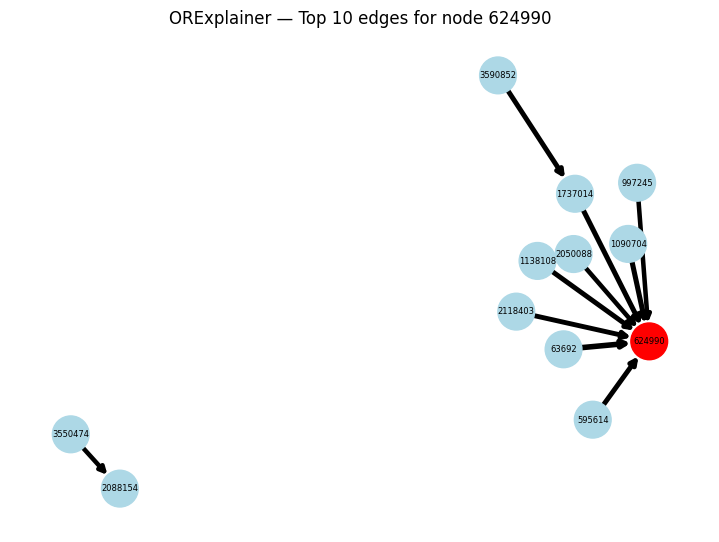

In [54]:
# This cell visualizes the top ORExplainer edges using the learned edge-level scores.

k_plot = 10

top_k_idx = edge_scores_ore.argsort(descending=True)[:k_plot]

important_edges_orig = torch.stack(
    [
        subset[sub_edge_index[0].cpu()[top_k_idx]],
        subset[sub_edge_index[1].cpu()[top_k_idx]],
    ]
)

edge_scores_topk = edge_scores_ore[top_k_idx]
node_idx = target_node_id

G = nx.DiGraph()

for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w = float(edge_scores_topk[i].item())

    G.add_edge(src, dst, weight=w)

pos = nx.spring_layout(G, scale=5, seed=18)

widths = [
    max(1.0, G[u][v]["weight"] * 4)
    for u, v in G.edges()
]

colors = [
    "red" if n == node_idx else "lightblue"
    for n in G.nodes()
]

plt.figure(figsize=(7, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    width=widths,
    node_size=700,
    font_size=6,
    arrows=True,
)

plt.title(f"ORExplainer — Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()

# 14. GNNShap



In [58]:
import os
import sys
import shutil
import subprocess


# Install dependencies required by GNNShap
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "colorlog",
        "ninja",
    ],
    check=True,
)

# Repository path
GNN_SHAP_REPO_DIR = "/content/GNNShap"

# Clone the repository only if needed
if not os.path.isdir(GNN_SHAP_REPO_DIR):
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/HipGraph/GNNShap.git",
            GNN_SHAP_REPO_DIR,
        ],
        check=True,
    )

# Move inside the repository because GNNShap uses relative paths internally
os.chdir(GNN_SHAP_REPO_DIR)

# Add repository to Python path
if GNN_SHAP_REPO_DIR not in sys.path:
    sys.path.insert(0, GNN_SHAP_REPO_DIR)

# Clear failed imports from previous attempts
for module_name in list(sys.modules.keys()):
    if module_name.startswith("gnnshap"):
        del sys.modules[module_name]

# Clear Torch C++ extension cache to force recompilation
torch_extensions_cache = os.path.expanduser("~/.cache/torch_extensions")

if os.path.isdir(torch_extensions_cache):
    shutil.rmtree(torch_extensions_cache)

# Limit parallel build jobs to avoid unstable CUDA compilation in Colab
os.environ["MAX_JOBS"] = "2"

# Optional CUDA architecture setting for common Colab GPUs
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5;8.0;8.6"

import gnnshap
from gnnshap.explainer import GNNShapExplainer


gnnshap_setup_summary = pd.DataFrame(
    {
        "Property": [
            "Repository",
            "Repository path",
            "Current working directory",
            "Imported package",
            "Explainer class",
            "Target original node ID",
        ],
        "Value": [
            "HipGraph/GNNShap",
            GNN_SHAP_REPO_DIR,
            os.getcwd(),
            "gnnshap",
            "GNNShapExplainer",
            target_node_id,
        ],
    }
)

display(gnnshap_setup_summary)

,Property,Value
0,Repository,HipGraph/GNNShap
1,Repository path,/content/GNNShap
2,Current working directory,/content/GNNShap
3,Imported package,gnnshap
4,Explainer class,GNNShapExplainer
5,Target original node ID,624990


In [61]:
# This cell initializes GNNShap using the trained GCN model already available in the notebook.

def forward_no_edge_weight(model, node_features, edge_index, node_idx, edge_weight=None):
    """Forward function required by GNNShap."""
    model.eval()

    with torch.no_grad():
        log_probs = model(node_features, edge_index)
        probs = log_probs.exp()[node_idx, :]

    return probs


# Use the trained GCN model from the notebook
model_gnnshap = model.to(device)
model_gnnshap.eval()

# Use the full DGraphFin graph
graph_data_gnnshap = graph_data.to(device)

GNN_SHAP_HOPS = 5

gshap = GNNShapExplainer(
    model_gnnshap,
    graph_data_gnnshap,
    nhops=GNN_SHAP_HOPS,
    verbose=0,
    device=device,
    forward_fn=forward_no_edge_weight,
    progress_hide=True,
)

gnnshap_init_summary = pd.DataFrame(
    {
        "Property": [
            "Explainer",
            "Base model",
            "Forward function",
            "Number of hops",
            "Device",
            "Target original node ID",
            "Target true label",
        ],
        "Value": [
            "GNNShapExplainer",
            "Trained GCN model",
            "forward_no_edge_weight",
            GNN_SHAP_HOPS,
            str(device),
            target_node_id,
            int(graph_data.y[target_node_id].item()),
        ],
    }
)

display(gnnshap_init_summary)

,Property,Value
0,Explainer,GNNShapExplainer
1,Base model,Trained GCN model
2,Forward function,forward_no_edge_weight
3,Number of hops,5
4,Device,cuda
5,Target original node ID,624990
6,Target true label,1


In [62]:
GNN_SHAP_NSAMPLES = 10000
GNN_SHAP_BATCH_SIZE = 1024
GNN_SHAP_SIZE_LIMIT = 3

explanation_gshap = gshap.explain(
    target_node_id,
    nsamples=GNN_SHAP_NSAMPLES,
    sampler_name="SVXSampler",
    batch_size=GNN_SHAP_BATCH_SIZE,
    solver_name="WLSSolver",
    size_lim=GNN_SHAP_SIZE_LIMIT,
)

gnnshap_result_summary = pd.DataFrame(
    {
        "Property": [
            "Explainer",
            "Target original node ID",
            "Number of samples",
            "Sampler",
            "Solver",
            "Size limit",
            "Returned object type",
        ],
        "Value": [
            "GNNShap",
            target_node_id,
            GNN_SHAP_NSAMPLES,
            "SVXSampler",
            "WLSSolver",
            GNN_SHAP_SIZE_LIMIT,
            type(explanation_gshap).__name__,
        ],
    }
)

display(gnnshap_result_summary)

,Property,Value
0,Explainer,GNNShap
1,Target original node ID,624990
2,Number of samples,10000
3,Sampler,SVXSampler
4,Solver,WLSSolver
5,Size limit,3
6,Returned object type,GNNShapExplanation


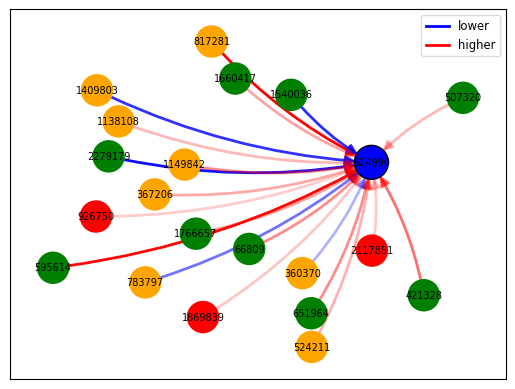

<Figure size 640x480 with 0 Axes>

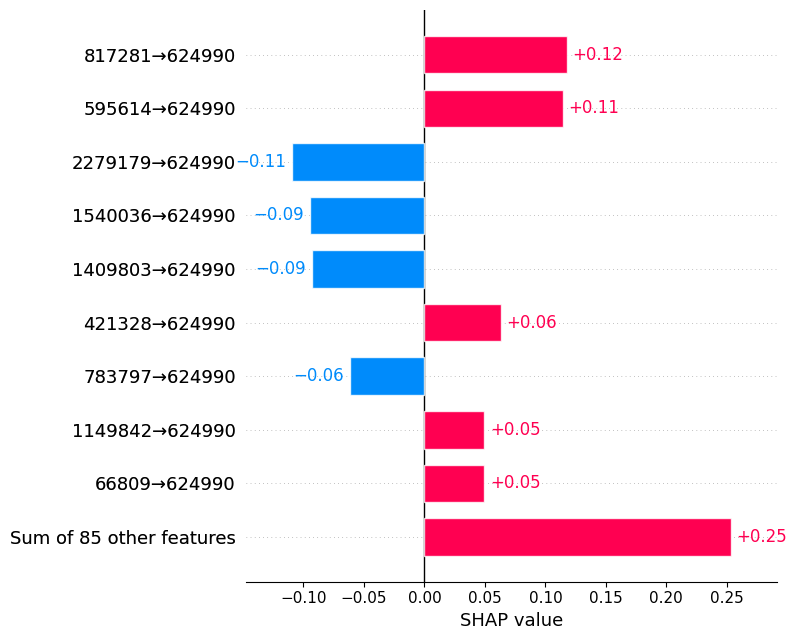

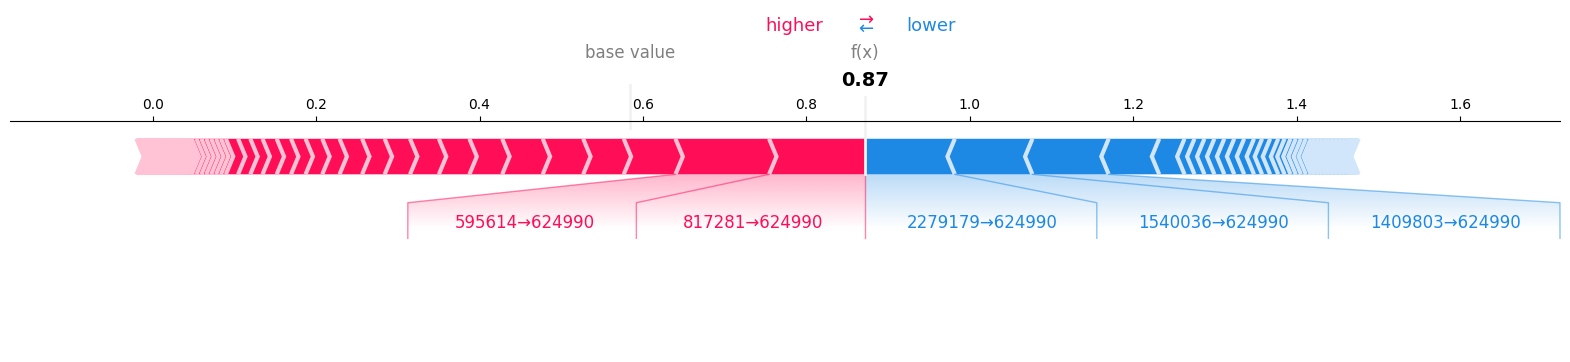

In [63]:
GNN_SHAP_TOP_K = 20

# Graph visualization
explanation_gshap.plot_graph(topk=GNN_SHAP_TOP_K)
plt.tight_layout()
plt.show()

# Bar plot
explanation_gshap.plot_bar(show=False)
plt.tight_layout()
plt.show()

# Force plot
explanation_gshap.plot_force(
    show_values=False,
    contrib_threshold=0.05,
)